# Módulo 9 · Tarea 4: Visualización

Gráficas con matplotlib a partir de `data/tareas_limpias.csv`. Ejecuta antes `m09-analisis.ipynb` para generar ese archivo.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

RUTA_LIMPIO = "../data/tareas_limpias.csv"
if not os.path.exists(RUTA_LIMPIO):
    raise FileNotFoundError("Falta data/tareas_limpias.csv: ejecuta primero m09-analisis.ipynb")

df = pd.read_csv(RUTA_LIMPIO, parse_dates=["fecha_creacion", "fecha_limite", "completado_en"])

AZUL = "#2a78d6"
COLORES_PRIORIDAD = {"alta": "#eb6834", "media": "#2a78d6", "baja": "#1baf7a"}
TEXTO = "#52514e"
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": TEXTO,
    "xtick.color": TEXTO,
    "ytick.color": TEXTO,
})
print("Tareas cargadas:", len(df))

Tareas cargadas: 10


## 1. Gráfico de barras: número de tareas por categoría

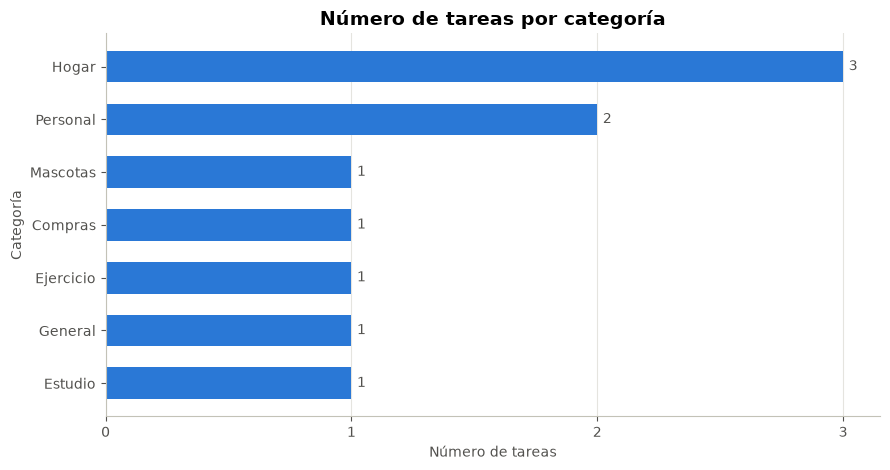

In [2]:
por_categoria = df["categoria"].value_counts().sort_values()

fig, ax = plt.subplots()
barras = ax.barh(por_categoria.index, por_categoria.values, color=AZUL, height=0.6)
ax.bar_label(barras, padding=4, color=TEXTO)
ax.set_title("Número de tareas por categoría")
ax.set_xlabel("Número de tareas")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel("Categoría")
ax.grid(axis="x", color="#e5e4df", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 2. Gráfico de líneas: tareas creadas en el tiempo

Conteo de tareas creadas por semana.

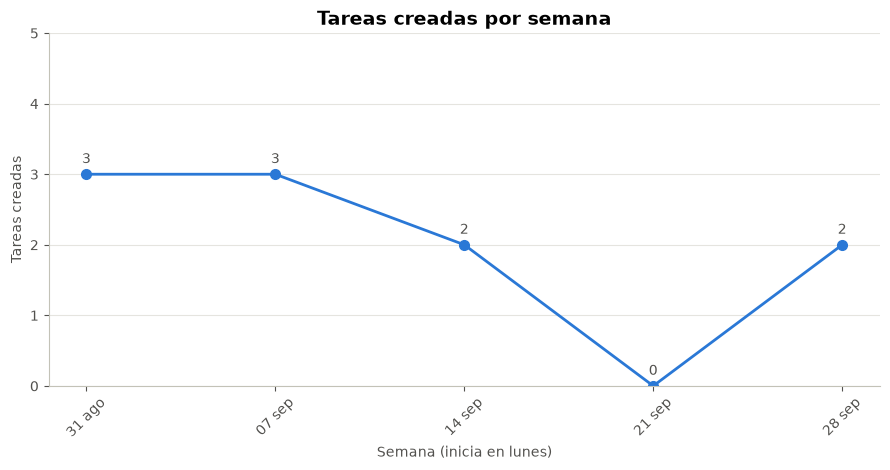

In [3]:
por_semana = df.set_index("fecha_creacion").resample("W-MON", label="left", closed="left")["id"].count()

fig, ax = plt.subplots()
ax.plot(por_semana.index, por_semana.values, color=AZUL, linewidth=2, marker="o", markersize=7)
for fecha, total in por_semana.items():
    ax.annotate(str(total), (fecha, total), textcoords="offset points", xytext=(0, 8), ha="center", color=TEXTO)
ax.set_title("Tareas creadas por semana")
ax.set_xlabel("Semana (inicia en lunes)")
ax.set_ylabel("Tareas creadas")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(0, por_semana.max() + 2)
ax.set_xticks(por_semana.index)
ax.set_xticklabels([f"{f.day:02d} {MESES[f.month - 1]}" for f in por_semana.index], rotation=45)
ax.grid(axis="y", color="#e5e4df", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 3. Gráfico circular: distribución de prioridades

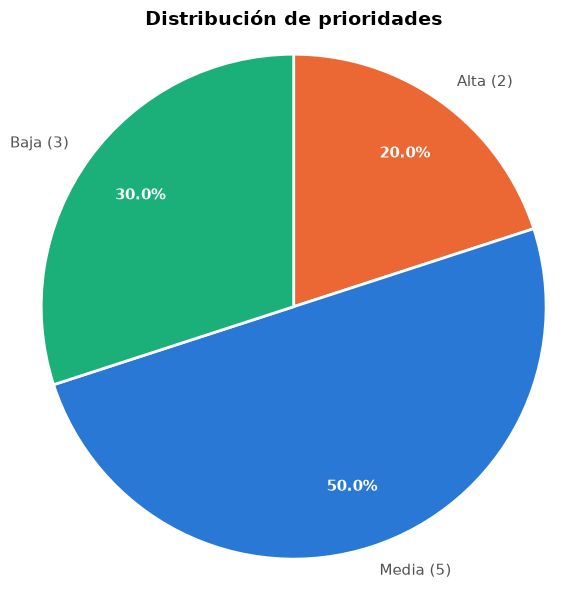

In [4]:
orden = ["alta", "media", "baja"]
por_prioridad = df["prioridad"].value_counts().reindex(orden, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 6))
_, _, porcentajes = ax.pie(
    por_prioridad.values,
    labels=[f"{p.capitalize()} ({n})" for p, n in por_prioridad.items()],
    colors=[COLORES_PRIORIDAD[p] for p in por_prioridad.index],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"color": TEXTO, "fontsize": 11},
)
for texto in porcentajes:
    texto.set_color("white")
    texto.set_fontweight("bold")
ax.set_title("Distribución de prioridades")
ax.axis("equal")
plt.tight_layout()
plt.show()